# TianoCore Survey EDA
## Section 9: Supply Chain

---

TianoCore Survey — EDA Section 9: Supply Chain (Q64–Q66)
=========================================================
  Q64 — Supply chain knowledge/involvement
  Q65 — Methods to verify upstream integrity (multi-select)
  Q66 — Main challenges in supply chain visibility (multi-select)

### Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Step 2 — Install dependencies (if needed)

In [2]:
!pip install matplotlib pandas -q

### Step 3 — Run analysis


Q64 — Supply Chain Knowledge (n=7/13):
  Yes: 4
  No: 3


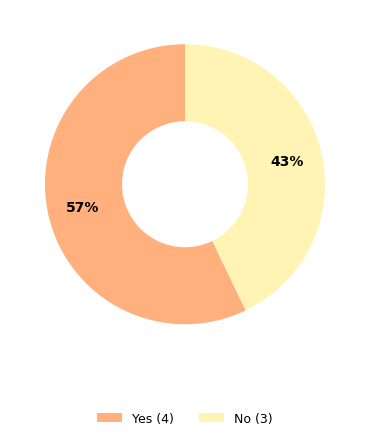

Saved: fig_58_supply_chain_knowledge.png

Q65 — Verify Upstream Integrity (n=4/13):
  Manual review of upstream code or releases: 4
  Monitoring CVEs or vulnerability databases: 3
  Tracking dependencies using internal documentation or spreadsheets: 2
  Automated dependency or supply-chain scanning tools: 2


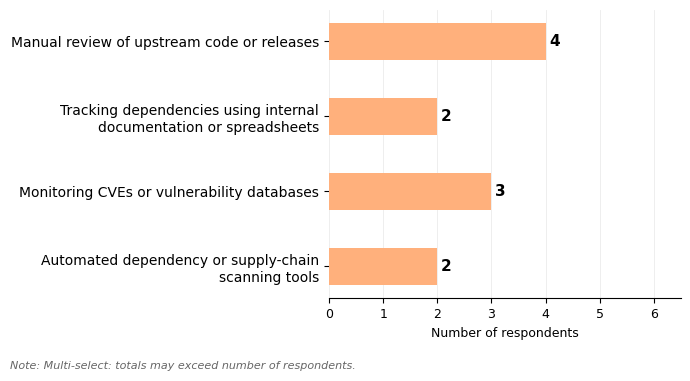

Saved: fig_59_verify_integrity.png

Q66 — Supply Chain Challenges (n=4/13):
  Scale or complexity of dependencies: 3
  Limited tooling support: 2
  Lack of standardized metadata: 2
  Performance or integration concerns: 1
  No major challenges: 1


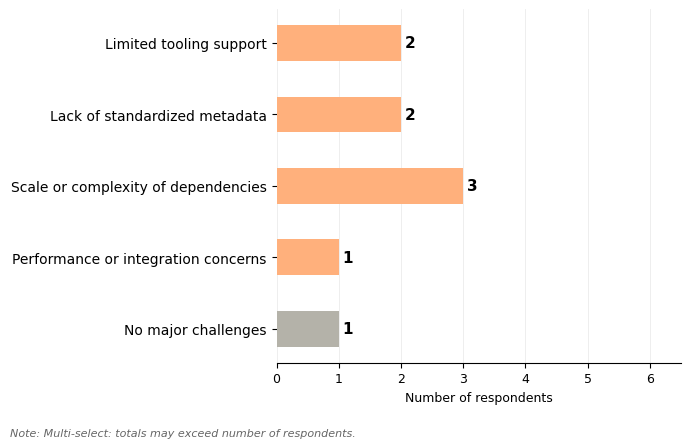

Saved: fig_60_supply_chain_challenges.png

✓ Section 9 (Supply Chain) complete.


In [3]:
import os, pandas as pd, matplotlib.pyplot as plt
from collections import Counter

CSV_PATH = "/content/drive/MyDrive/TS-Survey/tianocore-survey_cleaned.csv"
OUT_DIR  = "/content/drive/MyDrive/TS-Survey/figures"
os.makedirs(OUT_DIR, exist_ok=True)

C_MAIN = "#ffb07c"; C_SECOND = "#B4B2A9"
PIE_PALETTE = ["#ffb07c","#FFF4B3","#FFD7EE","#FAC775","#F0997B","#97C459","#B4B2A9"]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.grid": True, "axes.grid.axis": "x", "grid.color": "#ebebeb",
    "grid.linewidth": 0.6, "axes.axisbelow": True,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "xtick.labelsize": 9, "ytick.labelsize": 10,
})

df = pd.read_csv(CSV_PATH, header=0, skiprows=[1, 2]); N = len(df)

def simple_counts(col): return Counter(df[col].dropna().tolist())
def multi_counts(col):
    c = Counter()
    for val in df[col].dropna():
        for item in str(val).split(","):
            item = item.strip()
            if item: c[item] += 1
    return c
def wrap(label, width=44):
    words = label.split(); lines = []; cur = ""
    for w in words:
        if cur and len(cur)+1+len(w) > width: lines.append(cur); cur = w
        else: cur = (cur+" "+w).strip()
    if cur: lines.append(cur)
    return "\n".join(lines)
def pick(label):
    lo = label.lower()
    return C_SECOND if any(k in lo for k in ("other","specify","no major")) else C_MAIN
def save(fig, name):
    fig.savefig(os.path.join(OUT_DIR, name), dpi=150, bbox_inches="tight", facecolor="white")
    plt.show(); plt.close(fig); print(f"Saved: {name}")
def hbar(cnt, fname, max_x=None, note=""):
    if not cnt: print(f"Skipped {fname} — no data"); return
    items = list(cnt.items()); labels = [i[0] for i in items]; vals = [i[1] for i in items]
    fig, ax = plt.subplots(figsize=(7, max(2.5, 0.65*len(items)+1.0)))
    bars = ax.barh([wrap(l) for l in labels[::-1]], vals[::-1],
                   color=[pick(l) for l in labels[::-1]], height=0.5, zorder=3)
    ax.set_xlabel("Number of respondents", fontsize=9)
    ax.set_xlim(0, (max_x or max(vals))+1.5)
    for bar, v in zip(bars, vals[::-1]):
        if v > 0: ax.text(v+0.06, bar.get_y()+bar.get_height()/2, str(v), va="center", fontsize=11, fontweight="bold")
    if note: fig.text(0.02, -0.04, f"Note: {note}", fontsize=8, color="#666", ha="left", style="italic")
    fig.tight_layout(); save(fig, fname)
def pie(cnt, fname):
    if not cnt: return
    items = list(cnt.items()); labels = [i[0] for i in items]; vals = [i[1] for i in items]
    colours = [PIE_PALETTE[i % len(PIE_PALETTE)] for i in range(len(items))]
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    wedges, _, autotexts = ax.pie(vals, colors=colours, autopct="%1.0f%%",
                                   startangle=90, wedgeprops=dict(width=0.55), pctdistance=0.75)
    for at in autotexts: at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("black")
    ax.legend(wedges, [f"{l} ({v})" for l, v in zip(labels, vals)],
              loc="lower center", bbox_to_anchor=(0.5,-0.22), fontsize=9, frameon=False, ncol=2)
    fig.tight_layout(); save(fig, fname)

q64 = simple_counts("Q64")
print(f"\nQ64 — Supply Chain Knowledge (n={sum(q64.values())}/{N}):")
for k,v in q64.items(): print(f"  {k}: {v}")
pie(q64, "fig_58_supply_chain_knowledge.png")

q65 = multi_counts("Q65")
print(f"\nQ65 — Verify Upstream Integrity (n={df['Q65'].notna().sum()}/{N}):")
for k,v in q65.most_common(): print(f"  {k}: {v}")
hbar(q65, "fig_59_verify_integrity.png", max_x=5,
     note="Multi-select: totals may exceed number of respondents.")

q66 = multi_counts("Q66")
print(f"\nQ66 — Supply Chain Challenges (n={df['Q66'].notna().sum()}/{N}):")
for k,v in q66.most_common(): print(f"  {k}: {v}")
hbar(q66, "fig_60_supply_chain_challenges.png", max_x=5,
     note="Multi-select: totals may exceed number of respondents.")

print("\n✓ Section 9 (Supply Chain) complete.")